## Clustering Exercise: Customer Segmentation in E-commerce

### Overview
<a href="https://archive.ics.uci.edu/ml/datasets/online+retail">Online retail is a transnational data set</a> which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

| Column Name     | Description                                                         |
| --------------- | ------------------------------------------------------------------- |
| **InvoiceNo**   | Unique identifier for each transaction (a 6-digit integral number). |
| **StockCode**   | Product (item) code.                                                |
| **Description** | Product (item) name.                                                |
| **Quantity**    | The number of units of the product purchased per transaction.       |
| **InvoiceDate** | Date and time when the transaction occurred.                        |
| **UnitPrice**   | Price per unit of the product (in GBP).                             |
| **CustomerID**  | Unique identifier for each customer.                                |
| **Country**     | The name of the country where the customer resides.                 |


### Goal
We aim to develop suitable and efficient marketing strategy for each segement of the Customers. Therefore, clustering is required to find meaningful customers segments

### Approach
Apply K-means clustering to to segment customers based on existing behavior to predict how a new customer is likely to act in the future.  That should ensure the company can target its customers efficiently with a corresponding marketing strategy.

We will adopt the RFM analysis by calculating the three RFM metrics:
- R (Recency): Number of days since last purchase
- F (Frequency): Number of tracsactions
- M (Monetary): Total amount of transactions (revenue contributed).

We will use the RFM new variables as input for the clustering

<a id="1"></a> <br>
### 1. Import the basic packages and set the random seed

In [1]:
print("Start")

Start


In [2]:
# import required libraries for dataframe and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# import required libraries for clustering
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# to ensure reproducibility
np.random.seed(42)
rand_state = 42

### 2. Load and Preview the Data

Start by loading the dataset and inspecting the first few rows.

In [5]:
# Load the dataset
data=pd.read_csv('./OnlineRetail.csv', encoding= 'cp1252' , header=0)

# Preview the dataset
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


<a id="2"></a> <br>
### 3. Data Cleansing
- Drop rows with missing values.
- Remove any entries where `Quantity` or `UnitPrice` is zero or negative, as these entries likely represent errors.
- Filter out rows that don’t have a `CustomerID`, which is essential for segmentation.

In [6]:
data.shape

(541909, 8)

In [7]:
# check column types and existance of NaNs
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [28]:
# check the distribution of the features
data.describe()


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [29]:
# Drop rows with missing values
data.dropna(inplace=True)

# Remove rows with Quantity and UnitPrice <= 0
data = data[(data['Quantity'] > 0) & (data['UnitPrice'] > 0)]

# Confirm cleaned data
data.info()

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  str    
 1   StockCode    397884 non-null  str    
 2   Description  397884 non-null  str    
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  str    
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 27.3 MB


<a id="3"></a> <br>
### 4. Feature Engineering
For customer segmentation, it is often need to conduct an RFM analysis by calculating key metrics such as:
- R (Recency): Number of days since last purchase
- F (Frequency): Number of tracsactions
- M (Monetary): Total amount of transactions (revenue contributed).

In [30]:
from datetime import datetime

# Convert InvoiceDate to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Set the reference date (one day after the last transaction)
reference_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
#Total amount of transactions (revenue contributed)
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

1240000.614
0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 397884, dtype: float64


In [ ]:



# Compute RFM metrics per customer, you can break this code down to several lines if you feel it is too hard
rfm = (
    data.groupby(data.CustomerID.name) # type: ignore
        .aggregate(
            Recency=(data.InvoiceDate.name, lambda x: (reference_date - x.max()).days),
            Frequency=(data.InvoiceNo.name, lambda x: x.nunique()),
            Monetary=(data.TotalPrice.name, lambda x: x.max())
        )
        .reset_index()
)
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,249.60
2,12348.0,75,4,240.00
3,12349.0,19,1,300.00
4,12350.0,310,1,40.00
...,...,...,...,...
4333,18280.0,278,1,23.70
4334,18281.0,181,1,16.95
4335,18282.0,8,2,25.50
4336,18283.0,4,16,20.80


In [65]:
# Preview the RFM data
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.6
1,12347.0,2,7,249.6
2,12348.0,75,4,240.0
3,12349.0,19,1,300.0
4,12350.0,310,1,40.0


### 5. Data Exploration and Visualization

Use visualizations to understand the distributions of **Recency**, **Frequency**, and **Monetary** values.

<Axes: xlabel='Recency', ylabel='Count'>

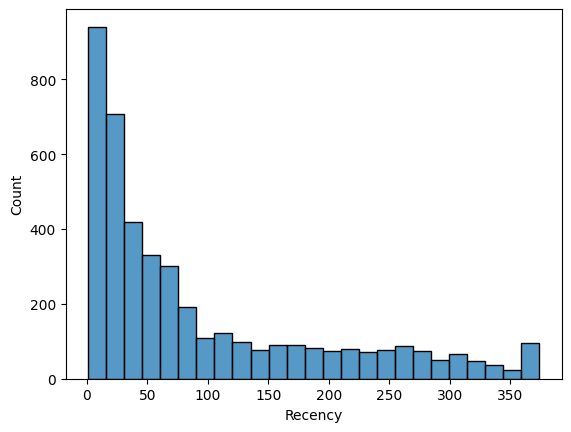

In [68]:
sns.histplot(rfm.Recency)

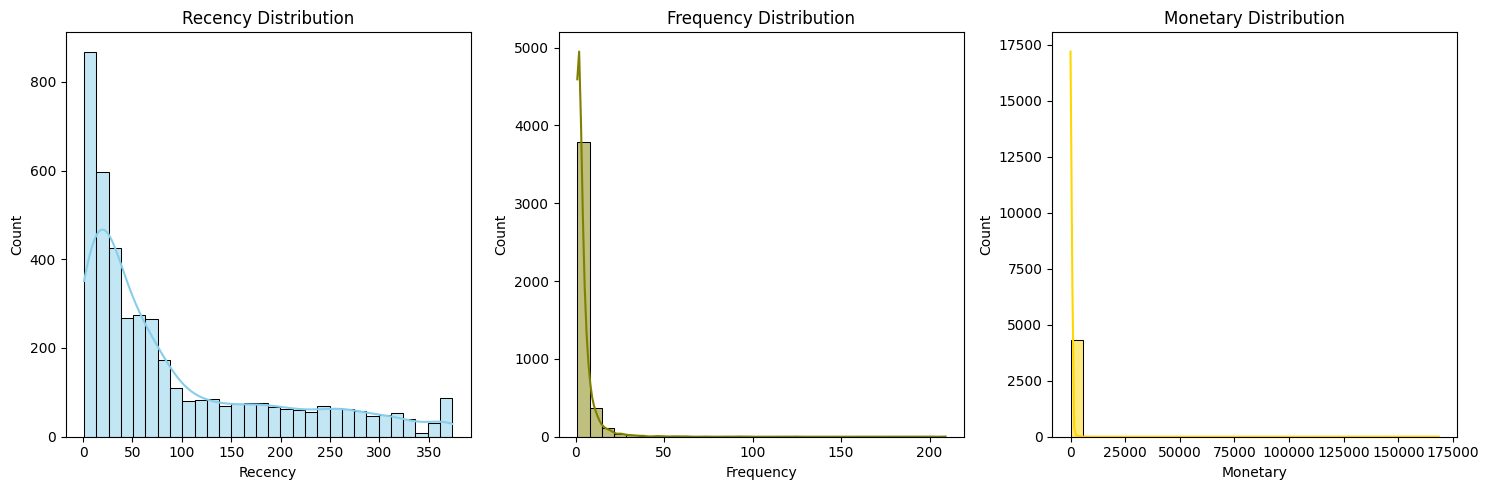

In [70]:
# Plot histograms for each RFM metric
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm['Recency'], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, kde=True, ax=axes[1], color="olive")
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, kde=True, ax=axes[2], color="gold")
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x14cb56ebc50>,
 'caps': [<matplotlib.lines.Line2D at 0x14cb56ebed0>,
 'boxes': [<matplotlib.lines.Line2D at 0x14cb56ebb10>],
 'medians': [<matplotlib.lines.Line2D at 0x14cb56e0190>],
 'fliers': [<matplotlib.lines.Line2D at 0x14cb56e02d0>],
 'means': []}

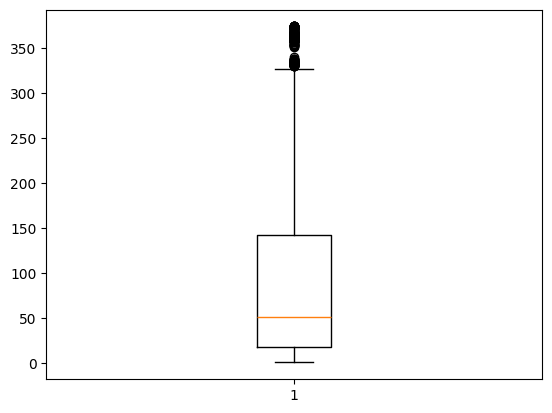

In [77]:
plt.boxplot(rfm.Recency)

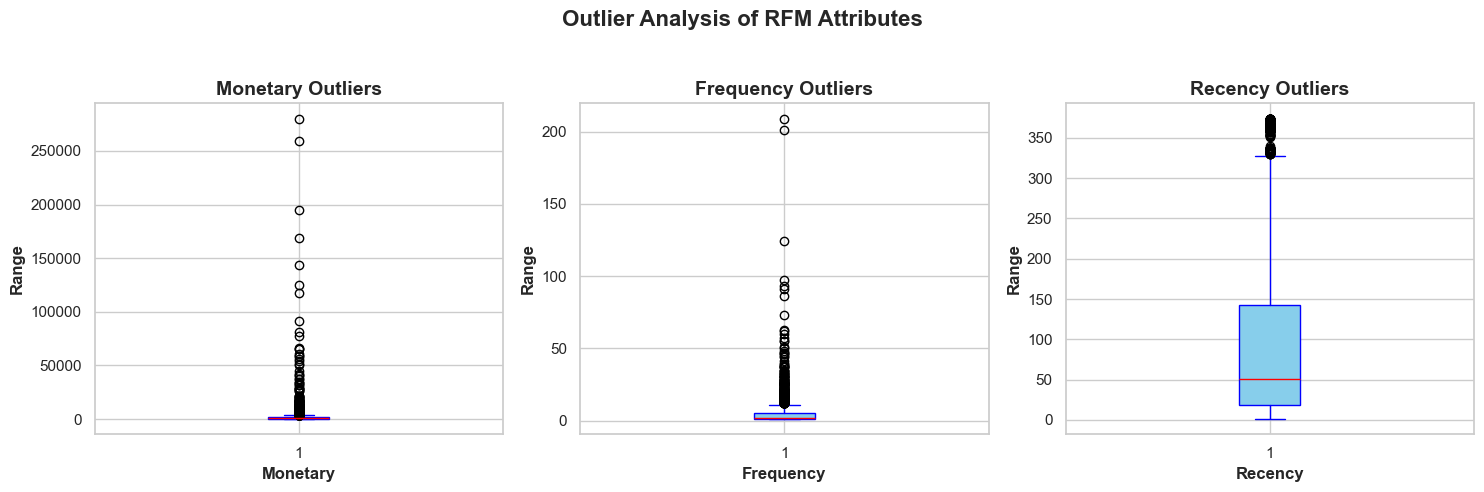

In [138]:
# Outlier Analysis of Amount, Frequency, and Recency
attributes = ['Monetary', 'Frequency', 'Recency']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each attribute in a separate subplot
for i, attr in enumerate(attributes):
    axes[i].boxplot(rfm[attr], vert=True, patch_artist=True, 
                    boxprops=dict(facecolor="skyblue", color="blue"),
                    medianprops=dict(color="red"),
                    whiskerprops=dict(color="blue"),
                    capprops=dict(color="blue"))
    
    # Set title and labels for each subplot
    axes[i].set_title(f"{attr} Outliers", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Range", fontweight='bold')
    axes[i].set_xlabel(attr, fontweight='bold')

# Adjust layout
plt.suptitle("Outlier Analysis of RFM Attributes", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Notice: An outlier: is an observation that lies an abnormal distance from other values in a random sample from a population. In a sense, this definition leaves it up to the analyst (or a consensus process) to decide what will be considered abnormal.

In [78]:
# Removing (statistical) outliers for Amount
Q1 = rfm.Monetary.quantile(0.05)
Q3 = rfm.Monetary.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Monetary >= Q1 - 1.5*IQR) & (rfm.Monetary <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5*IQR) & (rfm.Recency <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Frequency
Q1 = rfm.Frequency.quantile(0.05)
Q3 = rfm.Frequency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5*IQR) & (rfm.Frequency <= Q3 + 1.5*IQR)]

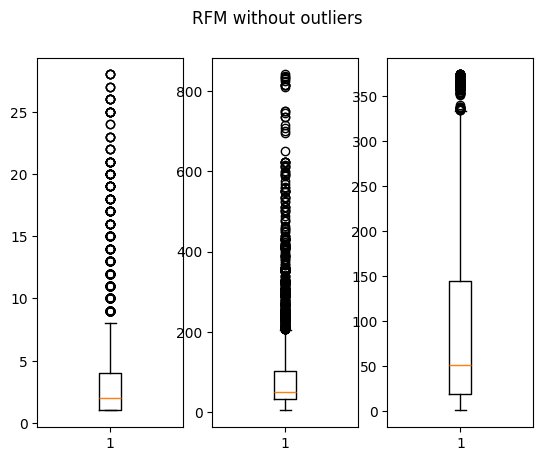

In [88]:
fig, axes = plt.subplots(1, 3)

axes[0].boxplot(rfm.Frequency)
axes[1].boxplot(rfm.Monetary)
axes[2].boxplot(rfm.Recency)

plt.suptitle("RFM without outliers")
plt.show()

### 5. Scaling Data for Clustering

StandardScaler removes the mean and scales the data to unit variance. The scaling shrinks the range of the feature values as shown in the left figure below. However, the outliers have an influence when computing the empirical mean and standard deviation. 

In [89]:
# Standardize the RFM metrics to improve clustering performance 
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Convert scaled data to DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

### 6. Determining the Optimal Number of Clusters (Elbow Method)

✅ Task for students: Use the Elbow Method to find the optimal number of clusters.

In [1]:
# your code here

### 7. Apply K-means Clustering

✅ Task for students: Using the chosen optimal `k` (e.g., 4), perform K-means clustering.

In [143]:
# your code here

In [144]:
# Preview clustered data
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
1,12347.0,2,7,4310.00,3
2,12348.0,75,4,1797.24,0
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,2
5,12352.0,36,8,2506.04,3


### 8. Cluster Insights and Interpretation
Interpret each cluster based on average **Recency**, **Frequency**, and **Monetary** average (mean) values across the clusters.
- find the mean value for each of the three variables for each cluster
- normalize this value by dividing it by maximum mean value across the different clusters: mean recency cluster 1/maximum mean of recency across all clusters

In [150]:
# Calculate average values per cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

# Display cluster summary
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         Recency  Frequency  Monetary
Cluster                              
0          51.26       2.30    683.72
1          18.63      15.58   7240.06
2         252.54       1.47    430.83
3          30.50       7.08   2738.73


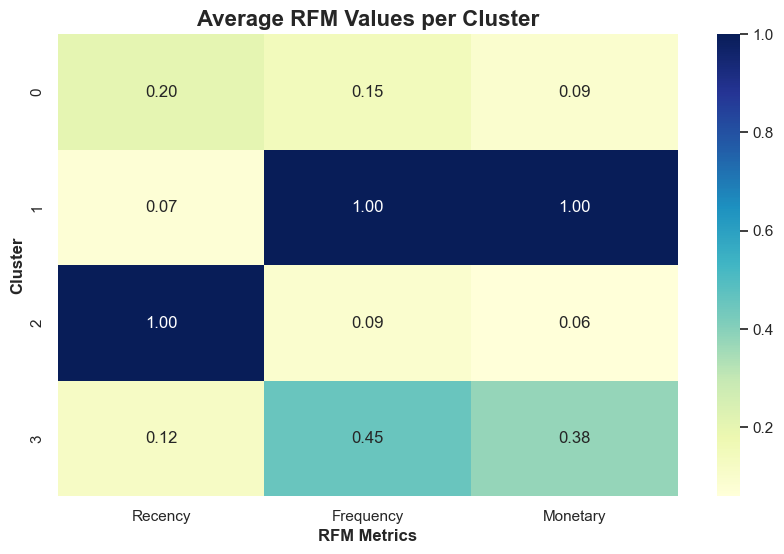

In [152]:
# normalize per feature. Otherwise, it is impossible to compare the clusters
cluster_summary/=cluster_summary.max(axis=0)

# Plot heatmap of cluster summary
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Average RFM Values per Cluster", fontsize=16, fontweight='bold')
plt.xlabel("RFM Metrics", fontweight='bold')
plt.ylabel("Cluster", fontweight='bold')
plt.show()


### 10. Conclusion and Recommendations

✅ Task for students: Discuss insights such as which customer segments are "high-value" or "at risk" of churning, and potential strategies to engage each segment.